# TP5 — Attribution Multicanal Lumina & Co

Objectif : construire un framework d'attribution neutre (heuristiques + Markov) et défendre des recommandations budgétaires au CMO.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

## Étape 1 — Exploration des parcours

In [23]:
try:
    touchpoints = pd.read_csv('touchpoints.csv')
    print('touchpoints.csv chargé')
except FileNotFoundError:
    print('ERREUR : touchpoints.csv non trouvé dans le répertoire courant')
    print('Assurez-vous que le fichier est dans le même dossier que ce notebook')
    raise

campaigns = pd.read_csv('campaigns.csv')

print(f'Touchpoints : {len(touchpoints):,} lignes | Colonnes : {list(touchpoints.columns)}')
print(f'Campaigns   : {len(campaigns)} lignes | Colonnes : {list(campaigns.columns)}')
display(touchpoints.head())
display(campaigns)

touchpoints.csv chargé
Touchpoints : 692,782 lignes | Colonnes : ['touchpoint_id', 'customer_id', 'invoice_id', 'campaign_name', 'timestamp', 'channel', 'position', 'n_touchpoints', 'click', 'converted', 'cost', 'is_last_before_conversion']
Campaigns   : 6 lignes | Colonnes : ['campaign_name', 'n_touchpoints', 'n_clients', 'n_clicks', 'n_conversions', 'total_cost', 'revenue', 'ctr', 'conversion_rate', 'cpa', 'roas', 'primary_channel', 'start_date', 'end_date']


,touchpoint_id,customer_id,invoice_id,campaign_name,timestamp,channel,position,n_touchpoints,click,converted,cost,is_last_before_conversion
0,0,12346,NaN,Summer_Sale,2011-01-12 13:53:03.779455317,affiliate,1,6,1,0,1.8698,0
1,1,12346,NaN,Summer_Sale,2011-01-13 09:39:01.945606194,social,2,6,0,0,0.9344,0
2,2,12346,NaN,Summer_Sale,2011-01-15 12:26:06.292806500,direct,3,6,1,0,0.0000,0
3,3,12346,NaN,Summer_Sale,2011-01-16 04:17:18.063426214,affiliate,4,6,1,0,1.8373,0
4,4,12346,NaN,Summer_Sale,2011-01-16 13:03:11.985655755,social,5,6,0,0,0.5099,0


,campaign_name,n_touchpoints,n_clients,n_clicks,n_conversions,total_cost,revenue,ctr,conversion_rate,cpa,roas,primary_channel,start_date,end_date
0,Back_to_School,106501,21673,67012,14620,88427.0133,2026605.710,0.6292,0.6746,6.05,22.92,social,2011-01-19 00:56:35.586234729,2011-03-27 12:47:12.467700466
1,Black_Friday,136500,22902,88139,20359,112105.7416,2887368.041,0.6457,0.8890,5.51,25.76,social,2011-03-14 19:00:56.677018172,2011-06-08 12:35:47.751601188
2,Spring_Launch,131335,22738,84480,19919,108146.6040,3683616.372,0.6432,0.8760,5.43,34.06,display,2011-09-11 18:46:45.264734454,2011-12-09 12:37:31.367602666
3,Summer_Sale,104513,21267,65619,14418,86572.7437,2031991.770,0.6279,0.6780,6.00,23.47,social,2010-11-26 18:16:20.929087523,2011-02-01 12:47:52.433916959
4,Valentine,106445,21477,66807,14903,88766.9194,2407033.030,0.6276,0.6939,5.96,27.12,affiliate,2011-07-19 16:20:54.099636323,2011-09-24 12:49:18.159297463
5,Winter_Promo,107488,21417,67709,14877,88989.8165,2184391.821,0.6299,0.6946,5.98,24.55,display,2011-05-27 05:25:24.559502836,2011-08-01 12:49:46.374670016


In [24]:

print('Colonnes touchpoints :', touchpoints.columns.tolist())
print('\nTypes :', touchpoints.dtypes)
print('\nAperçu :')
display(touchpoints.head(10))
display(touchpoints.describe(include='all'))

Colonnes touchpoints : ['touchpoint_id', 'customer_id', 'invoice_id', 'campaign_name', 'timestamp', 'channel', 'position', 'n_touchpoints', 'click', 'converted', 'cost', 'is_last_before_conversion']

Types : touchpoint_id                  int64
customer_id                    int64
invoice_id                   float64
campaign_name                    str
timestamp                        str
channel                          str
position                       int64
n_touchpoints                  int64
click                          int64
converted                      int64
cost                         float64
is_last_before_conversion      int64
dtype: object

Aperçu :


,touchpoint_id,customer_id,invoice_id,campaign_name,timestamp,channel,position,n_touchpoints,click,converted,cost,is_last_before_conversion
0,0,12346,NaN,Summer_Sale,2011-01-12 13:53:03.779455317,affiliate,1,6,1,0,1.8698,0
1,1,12346,NaN,Summer_Sale,2011-01-13 09:39:01.945606194,social,2,6,0,0,0.9344,0
2,2,12346,NaN,Summer_Sale,2011-01-15 12:26:06.292806500,direct,3,6,1,0,0.0000,0
3,3,12346,NaN,Summer_Sale,2011-01-16 04:17:18.063426214,affiliate,4,6,1,0,1.8373,0
4,4,12346,NaN,Summer_Sale,2011-01-16 13:03:11.985655755,social,5,6,0,0,0.5099,0
5,5,12346,541431.0,Summer_Sale,2011-01-18 07:13:05.806761399,retargeting,6,6,1,1,1.1154,1
6,6,12347,NaN,Summer_Sale,2011-01-21 09:38:29.208027606,social,1,4,1,0,0.8903,0
7,7,12347,NaN,Summer_Sale,2011-01-21 12:13:48.119006123,display,2,4,1,0,0.2358,0
8,8,12347,NaN,Summer_Sale,2011-01-22 17:50:53.777313490,search_paid,3,4,1,0,1.1592,0
9,9,12347,542237.0,Summer_Sale,2011-01-26 12:45:39.931008552,retargeting,4,4,1,1,0.8827,1


,touchpoint_id,customer_id,invoice_id,campaign_name,timestamp,channel,position,n_touchpoints,click,converted,cost,is_last_before_conversion
count,692782.000000,692782.000000,99096.000000,692782,692782,692782,692782.000000,692782.000000,692782.000000,692782.000000,692782.000000,692782.000000
unique,NaN,NaN,NaN,6,692780,7,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Black_Friday,2011-08-29 11:50:00.000000000,social,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,136500,2,120118,NaN,NaN,NaN,NaN,NaN,NaN
mean,346390.500000,29331.010276,655003.348410,NaN,NaN,NaN,2.912838,4.825677,0.634783,0.143041,0.827113,0.143041
std,199989.081432,14023.621368,67597.965965,NaN,NaN,NaN,1.807984,2.057820,0.481491,0.350115,0.785890,0.350115
min,0.000000,12346.000000,538032.000000,NaN,NaN,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,173195.250000,19188.000000,598201.750000,NaN,NaN,NaN,1.000000,3.000000,0.000000,0.000000,0.076000,0.000000
50%,346390.500000,21977.000000,648241.500000,NaN,NaN,NaN,2.000000,5.000000,1.000000,0.000000,0.693750,0.000000
75%,519585.750000,38851.000000,712757.500000,NaN,NaN,NaN,4.000000,6.000000,1.000000,0.000000,1.205800,0.000000


In [25]:
cols = touchpoints.columns.str.lower().tolist()

cid_col = next((c for c in touchpoints.columns if 'customer' in c.lower() or 'uid' in c.lower() or 'user' in c.lower() or 'client' in c.lower()), touchpoints.columns[0])

chan_col = next((c for c in touchpoints.columns if 'channel' in c.lower() or 'media' in c.lower() or 'source' in c.lower()), None)

ts_col = next((c for c in touchpoints.columns if 'time' in c.lower() or 'date' in c.lower() or 'ts' in c.lower()), None)

conv_col = next((c for c in touchpoints.columns if 'conv' in c.lower()), None)

camp_col = next((c for c in touchpoints.columns if 'campaign' in c.lower() or 'camp' in c.lower()), None)

print(f'Colonnes détectées automatiquement :')
print(f'  client_id  : {cid_col}')
print(f'  channel    : {chan_col}')
print(f'  timestamp  : {ts_col}')
print(f'  conversion : {conv_col}')
print(f'  campaign   : {camp_col}')
print()
print(' Vérifiez et corrigez manuellement si nécessaire')

Colonnes détectées automatiquement :
  client_id  : customer_id
  channel    : channel
  timestamp  : timestamp
  conversion : converted
  campaign   : campaign_name

 Vérifiez et corrigez manuellement si nécessaire


In [26]:
rename_map = {}
if cid_col: rename_map[cid_col] = 'customer_id'
if chan_col: rename_map[chan_col] = 'channel'
if ts_col:  rename_map[ts_col]  = 'timestamp'
if conv_col: rename_map[conv_col] = 'converted'
if camp_col: rename_map[camp_col] = 'campaign'

tp = touchpoints.rename(columns=rename_map).copy()

if 'timestamp' in tp.columns:
    tp['timestamp'] = pd.to_datetime(tp['timestamp'], errors='coerce')
    tp = tp.sort_values(['customer_id', 'timestamp'])

if 'channel' not in tp.columns:
    
    if 'campaign' in tp.columns:
        tp['channel'] = tp['campaign']
        print('→ channel déduit de la colonne campaign')
    else:
        tp['channel'] = tp.iloc[:, 1].astype(str)
        print('→ channel déduit de la 2e colonne')

print(f'\nCanaux disponibles : {tp.channel.nunique()}')
print(tp['channel'].value_counts().head(10))

if 'converted' in tp.columns:
    print(f'\nTaux de conversion global : {tp.converted.mean()*100:.2f}%')
    n_conversions = tp.converted.sum()
    print(f'Conversions totales : {n_conversions:,}')


Canaux disponibles : 7
channel
social         120118
display        119905
affiliate      119871
retargeting     97035
email           96857
direct          69636
search_paid     69360
Name: count, dtype: int64

Taux de conversion global : 14.30%
Conversions totales : 99,096


In [27]:
def build_journeys(df):
    journeys = []
    
    for cid, group in df.groupby('customer_id'):
        group = group.sort_values('timestamp') if 'timestamp' in group.columns else group
        channels = group['channel'].tolist()
        converted = int(group['converted'].max()) if 'converted' in group.columns else 0
        
        if 'timestamp' in group.columns and len(group) > 1:
            duration = (group['timestamp'].max() - group['timestamp'].min()).days
        else:
            duration = 0
        
        journeys.append({
            'customer_id': cid,
            'path': ' > '.join(channels),
            'channels': channels,
            'n_touchpoints': len(channels),
            'converted': converted,
            'duration_days': duration,
            'first_channel': channels[0] if channels else None,
            'last_channel': channels[-1] if channels else None
        })
    
    return pd.DataFrame(journeys)

print('Construction des parcours...')
journeys = build_journeys(tp)
print(f'Parcours construits : {len(journeys):,}')
display(journeys.describe())

Construction des parcours...
Parcours construits : 47,834


,customer_id,n_touchpoints,converted,duration_days
count,47834.000000,47834.000000,47834.000000,47834.000000
mean,38351.277606,14.483046,0.580194,172.915499
std,14625.220513,36.839908,0.493532,118.106476
min,12346.000000,1.000000,0.000000,0.000000
25%,25826.250000,4.000000,0.000000,46.000000
50%,38459.500000,7.000000,1.000000,193.000000
75%,51043.750000,14.000000,1.000000,276.000000
max,63441.000000,1559.000000,1.000000,375.000000


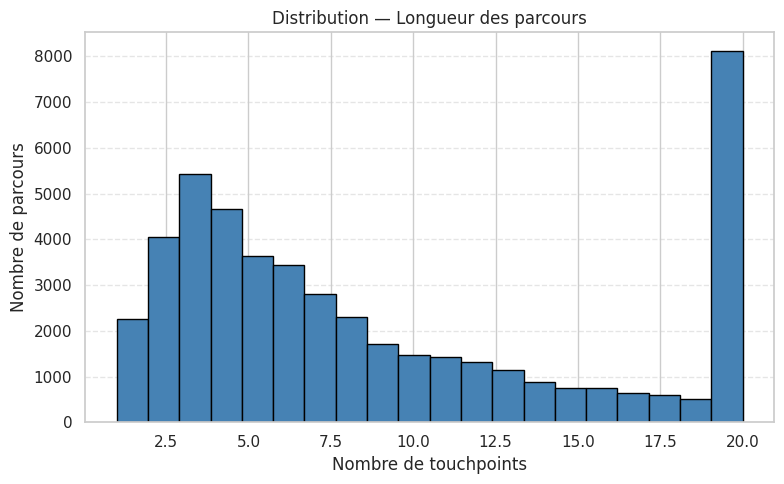

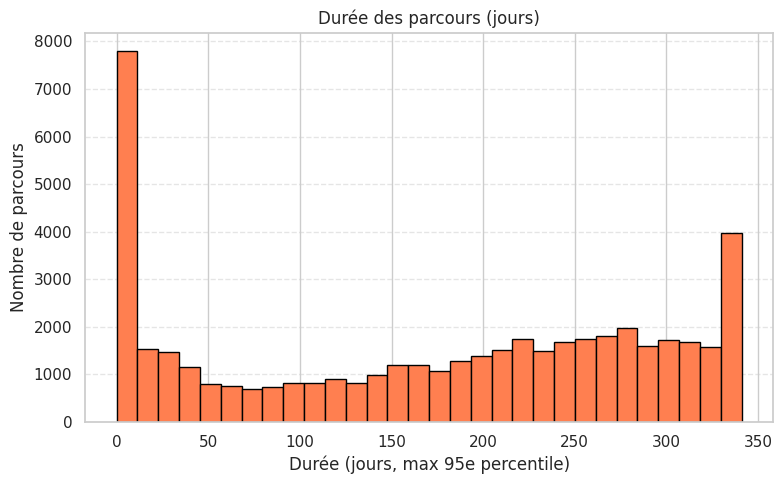

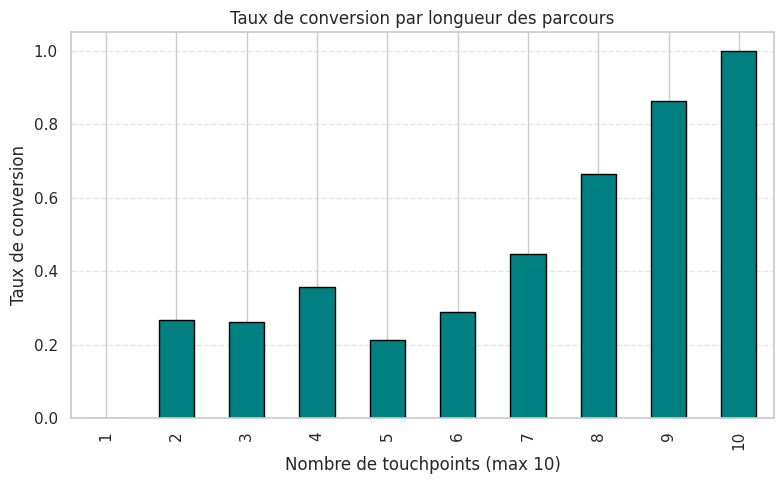


Canaux les plus fréquents en 1ère position :
first_channel
display        12950
social         12866
affiliate      12753
email           4669
retargeting     4596
Name: count, dtype: int64

Canaux les plus fréquents en dernière position (avant conversion) :
last_channel
retargeting    5896
email          5837
search_paid    4193
direct         4168
display        2569
affiliate      2556
Name: count, dtype: int64


In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
journeys['n_touchpoints'].clip(upper=20).hist(bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution — Longueur des parcours')
plt.xlabel('Nombre de touchpoints')
plt.ylabel('Nombre de parcours')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('journey_length_distribution.png', dpi=120)
plt.show()

plt.figure(figsize=(8, 5))
journeys['duration_days'].clip(upper=journeys['duration_days'].quantile(0.95)).hist(bins=30, color='coral', edgecolor='black')
plt.title('Durée des parcours (jours)')
plt.xlabel('Durée (jours, max 95e percentile)')
plt.ylabel('Nombre de parcours')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('journey_duration_distribution.png', dpi=120)
plt.show()

conv_by_length = journeys.groupby(journeys['n_touchpoints'].clip(upper=10))['converted'].mean()
plt.figure(figsize=(8, 5))
conv_by_length.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Taux de conversion par longueur des parcours')
plt.xlabel('Nombre de touchpoints (max 10)')
plt.ylabel('Taux de conversion')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('conversion_by_length.png', dpi=120)
plt.show()

print('\nCanaux les plus fréquents en 1ère position :')
print(journeys['first_channel'].value_counts().head(6))

print('\nCanaux les plus fréquents en dernière position (avant conversion) :')
conv_journeys = journeys[journeys['converted'] == 1]
print(conv_journeys['last_channel'].value_counts().head(6))

## Étape 2 — Modèles heuristiques

In [29]:
converted_journeys = journeys[journeys['converted'] == 1].copy()
n_total_conversions = len(converted_journeys)
print(f'Parcours convertis : {n_total_conversions:,}')

channels_list = tp['channel'].unique().tolist()
print(f'Canaux : {channels_list}')

def get_attribution_scores(method='first_touch'):
    """Calcule l'attribution par canal selon la méthode choisie."""
    scores = defaultdict(float)
    
    for _, row in converted_journeys.iterrows():
        path = row['channels']
        if not path:
            continue
        n = len(path)
        
        if method == 'first_touch':
            scores[path[0]] += 1
        
        elif method == 'last_touch':
            scores[path[-1]] += 1
        
        elif method == 'linear':
            for ch in path:
                scores[ch] += 1 / n
        
        elif method == 'time_decay':
            # Poids exponentiel croissant vers la fin
            weights = np.exp(np.linspace(0, 2, n))
            weights /= weights.sum()
            for ch, w in zip(path, weights):
                scores[ch] += w
        
        elif method == 'u_shape':
            # 40% premier, 40% dernier, 20% distribué
            if n == 1:
                scores[path[0]] += 1
            elif n == 2:
                scores[path[0]] += 0.5
                scores[path[-1]] += 0.5
            else:
                scores[path[0]] += 0.4
                scores[path[-1]] += 0.4
                middle_weight = 0.2 / (n - 2)
                for ch in path[1:-1]:
                    scores[ch] += middle_weight
    
    total = sum(scores.values())
    return {k: v / total * 100 for k, v in scores.items()}

methods = ['first_touch', 'last_touch', 'linear', 'time_decay', 'u_shape']
attribution_results = {}

for method in methods:
    attribution_results[method] = get_attribution_scores(method)
    print(f'{method} : {attribution_results[method]}')

Parcours convertis : 27,753
Canaux : ['affiliate', 'social', 'direct', 'retargeting', 'display', 'search_paid', 'email']
first_touch : {'affiliate': 29.14279537347314, 'social': 29.517529636435704, 'email': 5.804777861852772, 'retargeting': 5.768745721183296, 'display': 29.76615140705509}
last_touch : {'retargeting': 21.244550138723742, 'search_paid': 15.10827658271178, 'email': 21.031960508773825, 'affiliate': 9.209815155118365, 'social': 9.130544445645516, 'direct': 15.018196231038086, 'display': 9.256656937988685}
linear : {'affiliate': 17.466630980311685, 'social': 17.46222316102474, 'direct': 9.951520062006887, 'retargeting': 13.769329827325244, 'display': 17.611857574114932, 'search_paid': 9.862499073957576, 'email': 13.87593932125894}
time_decay : {'affiliate': np.float64(14.974016891011175), 'social': np.float64(14.875018248262894), 'direct': np.float64(11.77867196211116), 'retargeting': np.float64(15.73098557753535), 'display': np.float64(15.107190897991027), 'search_paid': np

## Étape 3 — Modèle de Markov

Construction de la matrice de transition Markov...
États : ['Conversion', 'Null', 'Start', 'affiliate', 'direct', 'display', 'email', 'retargeting', 'search_paid', 'social']


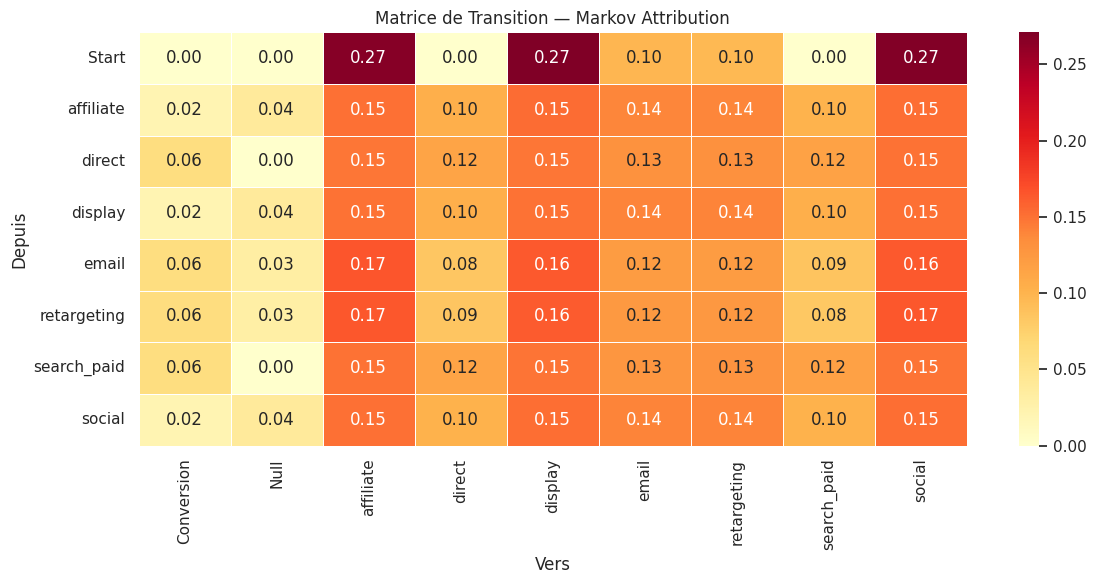

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

def build_transition_matrix(journeys_df):
    transitions = defaultdict(lambda: defaultdict(int))
    
    for path, converted in zip(journeys_df['channels'], journeys_df['converted']):
        full_path = ['Start'] + path + (['Conversion'] if converted else ['Null'])
        for i in range(len(full_path) - 1):
            transitions[full_path[i]][full_path[i + 1]] += 1
    
    all_states = sorted({s for k, v in transitions.items() for s in [k, *v.keys()]})
    idx = {s: i for i, s in enumerate(all_states)}
    
    n = len(all_states)
    matrix = np.zeros((n, n))
    for from_s, to_dict in transitions.items():
        total = sum(to_dict.values())
        for to_s, count in to_dict.items():
            matrix[idx[from_s], idx[to_s]] = count / total
    
    return pd.DataFrame(matrix, index=all_states, columns=all_states)

print('Construction de la matrice de transition Markov...')
trans_matrix = build_transition_matrix(journeys)
print(f'États : {trans_matrix.index.tolist()}')

channel_states = [s for s in trans_matrix.index if s not in ['Start', 'Conversion', 'Null']]
sub_states = ['Start'] + channel_states
sub_matrix = trans_matrix.loc[sub_states, [c for c in trans_matrix.columns if c != 'Start']]

plt.figure(figsize=(12, 6))
sns.heatmap(sub_matrix.round(3), annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Matrice de Transition — Markov Attribution')
plt.xlabel('Vers')
plt.ylabel('Depuis')
plt.tight_layout()
plt.savefig('tp5_markov_matrix.png', dpi=120)
plt.show()

In [31]:
def compute_conversion_probability(trans_matrix):
    """Calcule la probabilité de conversion globale depuis Start."""
    states = trans_matrix.index.tolist()
    if 'Conversion' not in states:
        return 0

    if 'Start' not in states:
        return 0

    absorbing = ['Conversion', 'Null']
    transient = [s for s in states if s not in absorbing]
    
    Q = trans_matrix.loc[transient, transient].values
    R = trans_matrix.loc[transient, absorbing].values if all(a in trans_matrix.columns for a in absorbing) else None
    
    if R is None:
        return float(trans_matrix.loc['Start', 'Conversion']) if 'Conversion' in trans_matrix.columns else 0
    
    try:
        N = np.linalg.inv(np.eye(len(transient)) - Q) 
        B = N @ R 
        state_idx = {s: i for i, s in enumerate(transient)}
        conv_idx = absorbing.index('Conversion')
        start_i = state_idx.get('Start', 0)
        return B[start_i, conv_idx]
    except np.linalg.LinAlgError:
        return float(trans_matrix.loc['Start', 'Conversion']) if 'Conversion' in trans_matrix.columns else 0

baseline_conv_prob = compute_conversion_probability(trans_matrix)
print(f'Probabilité de conversion baseline : {baseline_conv_prob:.4f}')

removal_effects = {}

for channel in channel_states:
    journeys_without = journeys.copy()
    journeys_without['channels'] = journeys_without['channels'].apply(
        lambda path: [c for c in path if c != channel]
    )
    journeys_without = journeys_without[journeys_without['channels'].str.len() > 0]
    
    if len(journeys_without) == 0:
        removal_effects[channel] = 1.0
        continue
    
    trans_without = build_transition_matrix(journeys_without)
    conv_without = compute_conversion_probability(trans_without)
    
    if baseline_conv_prob > 0:
        removal_effect = (baseline_conv_prob - conv_without) / baseline_conv_prob
    else:
        removal_effect = 0
    
    removal_effects[channel] = max(removal_effect, 0)
    print(f'  {channel}: effet suppression = {removal_effect:.4f} ({removal_effect*100:.1f}%)')

total_effect = sum(removal_effects.values())
markov_attribution = {k: v / total_effect * 100 if total_effect > 0 else 100/len(removal_effects)
                      for k, v in removal_effects.items()}
attribution_results['markov'] = markov_attribution
print('\nAttribution Markov :')
for k, v in sorted(markov_attribution.items(), key=lambda x: -x[1]):
    print(f'  {k}: {v:.1f}%')

Probabilité de conversion baseline : 0.5802
  affiliate: effet suppression = -0.0158 (-1.6%)
  direct: effet suppression = -0.0000 (-0.0%)
  display: effet suppression = -0.0165 (-1.6%)
  email: effet suppression = -0.0095 (-0.9%)
  retargeting: effet suppression = -0.0092 (-0.9%)
  search_paid: effet suppression = 0.0000 (0.0%)
  social: effet suppression = -0.0154 (-1.5%)

Attribution Markov :
  affiliate: 14.3%
  direct: 14.3%
  display: 14.3%
  email: 14.3%
  retargeting: 14.3%
  search_paid: 14.3%
  social: 14.3%


## Étape 4 — Comparaison des modèles

=== TABLEAU COMPARATIF D'ATTRIBUTION (% budget attribué) ===


,first_touch,last_touch,linear,time_decay,u_shape,markov
affiliate,29.14,9.21,17.47,14.97,18.78,14.29
direct,0.00,15.02,9.95,11.78,8.09,14.29
display,29.77,9.26,17.61,15.11,19.06,14.29
email,5.80,21.03,13.88,15.84,13.54,14.29
retargeting,5.77,21.24,13.77,15.73,13.57,14.29
search_paid,0.00,15.11,9.86,11.69,8.10,14.29
social,29.52,9.13,17.46,14.88,18.87,14.29


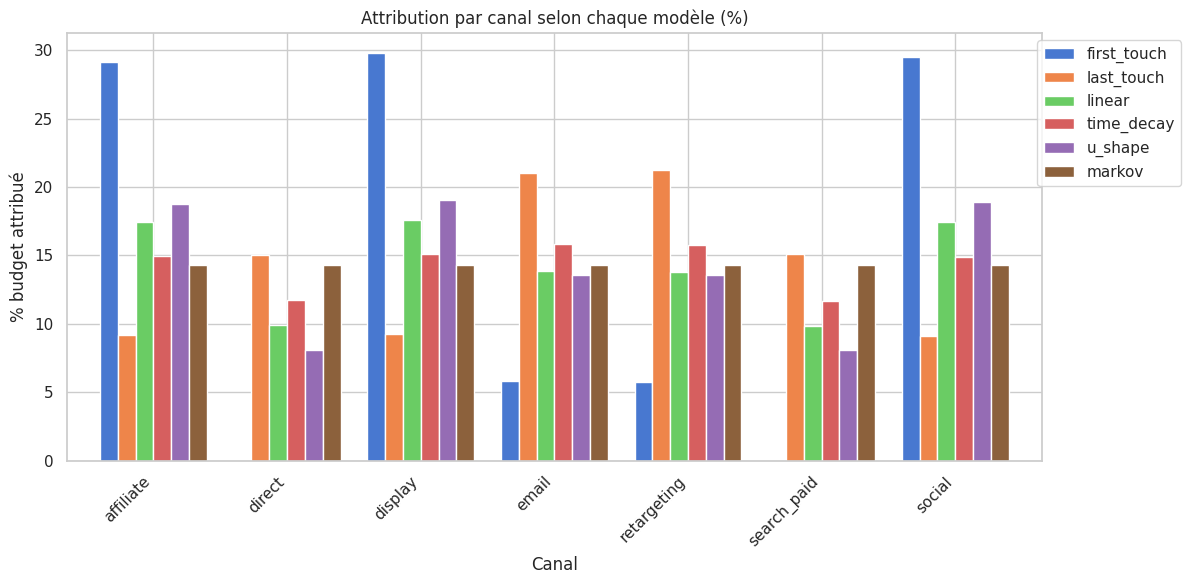

In [32]:
all_channels = sorted(set(
    list(markov_attribution.keys()) +
    list(attribution_results['last_touch'].keys())
))

comparison = pd.DataFrame(index=all_channels)
for method, scores in attribution_results.items():
    comparison[method] = comparison.index.map(lambda c: scores.get(c, 0))

comparison = comparison.round(2)
print('=== TABLEAU COMPARATIF D\'ATTRIBUTION (% budget attribué) ===')
display(comparison)

fig, ax = plt.subplots(figsize=(12, 6))
comparison.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Attribution par canal selon chaque modèle (%)')
ax.set_xlabel('Canal')
ax.set_ylabel('% budget attribué')
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('tp5_attribution_comparison.png', dpi=120)
plt.show()

In [33]:
comparison['delta_last_vs_markov'] = comparison['last_touch'] - comparison['markov']
print('\nDelta Last-Touch vs Markov (+ = surévalué par last-touch, - = sous-évalué) :')
display(comparison[['last_touch', 'markov', 'delta_last_vs_markov']].sort_values('delta_last_vs_markov', ascending=False))

over = comparison[comparison['delta_last_vs_markov'] > 2].index.tolist()
under = comparison[comparison['delta_last_vs_markov'] < -2].index.tolist()
print(f'\nCanaux surévalués par last-touch  : {over}')
print(f'Canaux réhabilités par Markov     : {under}')
print('→ Si le CMO avait basé ses décisions sur le last-touch, ces canaux auraient été sous-investis :', under)


Delta Last-Touch vs Markov (+ = surévalué par last-touch, - = sous-évalué) :


,last_touch,markov,delta_last_vs_markov
retargeting,21.24,14.29,6.95
email,21.03,14.29,6.74
search_paid,15.11,14.29,0.82
direct,15.02,14.29,0.73
display,9.26,14.29,-5.03
affiliate,9.21,14.29,-5.08
social,9.13,14.29,-5.16



Canaux surévalués par last-touch  : ['email', 'retargeting']
Canaux réhabilités par Markov     : ['affiliate', 'display', 'social']
→ Si le CMO avait basé ses décisions sur le last-touch, ces canaux auraient été sous-investis : ['affiliate', 'display', 'social']


## Étape 5 — KPIs par canal & recommandations budgétaires

In [34]:
campaigns = pd.read_csv('campaigns.csv')
display(campaigns)

total_revenue = campaigns['revenue'].sum()
total_cost = campaigns['total_cost'].sum()
total_conversions = campaigns['n_conversions'].sum()

print(f'CA total : {total_revenue:,.0f}€')
print(f'Budget total : {total_cost:,.0f}€')
print(f'Conversions totales : {total_conversions:,}')

,campaign_name,n_touchpoints,n_clients,n_clicks,n_conversions,total_cost,revenue,ctr,conversion_rate,cpa,roas,primary_channel,start_date,end_date
0,Back_to_School,106501,21673,67012,14620,88427.0133,2026605.710,0.6292,0.6746,6.05,22.92,social,2011-01-19 00:56:35.586234729,2011-03-27 12:47:12.467700466
1,Black_Friday,136500,22902,88139,20359,112105.7416,2887368.041,0.6457,0.8890,5.51,25.76,social,2011-03-14 19:00:56.677018172,2011-06-08 12:35:47.751601188
2,Spring_Launch,131335,22738,84480,19919,108146.6040,3683616.372,0.6432,0.8760,5.43,34.06,display,2011-09-11 18:46:45.264734454,2011-12-09 12:37:31.367602666
3,Summer_Sale,104513,21267,65619,14418,86572.7437,2031991.770,0.6279,0.6780,6.00,23.47,social,2010-11-26 18:16:20.929087523,2011-02-01 12:47:52.433916959
4,Valentine,106445,21477,66807,14903,88766.9194,2407033.030,0.6276,0.6939,5.96,27.12,affiliate,2011-07-19 16:20:54.099636323,2011-09-24 12:49:18.159297463
5,Winter_Promo,107488,21417,67709,14877,88989.8165,2184391.821,0.6299,0.6946,5.98,24.55,display,2011-05-27 05:25:24.559502836,2011-08-01 12:49:46.374670016


CA total : 15,221,007€
Budget total : 573,009€
Conversions totales : 99,096


In [35]:
kpis = pd.DataFrame({
    'channel': list(markov_attribution.keys()),
    'markov_share': [v / 100 for v in markov_attribution.values()]
})

kpis['revenue_attributed'] = kpis['markov_share'] * total_revenue
kpis['cost_attributed'] = kpis['markov_share'] * total_cost
kpis['conversions_attributed'] = kpis['markov_share'] * total_conversions

kpis['roas_markov'] = kpis['revenue_attributed'] / kpis['cost_attributed'].clip(lower=0.01)

kpis['cac'] = kpis['cost_attributed'] / kpis['conversions_attributed'].clip(lower=0.01)

last_touch_shares = {k: v/100 for k, v in attribution_results['last_touch'].items()}
kpis['last_touch_share'] = kpis['channel'].map(last_touch_shares).fillna(0)
kpis['roas_last_touch'] = (kpis['last_touch_share'] * total_revenue) / (kpis['last_touch_share'] * total_cost).clip(lower=0.01)

kpis['roas_delta'] = kpis['roas_markov'] - kpis['roas_last_touch']

print('=== KPIs PAR CANAL (Attribution Markov) ===')
display(kpis.sort_values('roas_markov', ascending=False).round(2))

=== KPIs PAR CANAL (Attribution Markov) ===


,channel,markov_share,revenue_attributed,cost_attributed,conversions_attributed,roas_markov,cac,last_touch_share,roas_last_touch,roas_delta
0,affiliate,0.14,2174429.53,81858.41,14156.57,26.56,5.78,0.09,26.56,0.0
1,direct,0.14,2174429.53,81858.41,14156.57,26.56,5.78,0.15,26.56,0.0
2,display,0.14,2174429.53,81858.41,14156.57,26.56,5.78,0.09,26.56,0.0
3,email,0.14,2174429.53,81858.41,14156.57,26.56,5.78,0.21,26.56,0.0
4,retargeting,0.14,2174429.53,81858.41,14156.57,26.56,5.78,0.21,26.56,0.0
5,search_paid,0.14,2174429.53,81858.41,14156.57,26.56,5.78,0.15,26.56,0.0
6,social,0.14,2174429.53,81858.41,14156.57,26.56,5.78,0.09,26.56,0.0


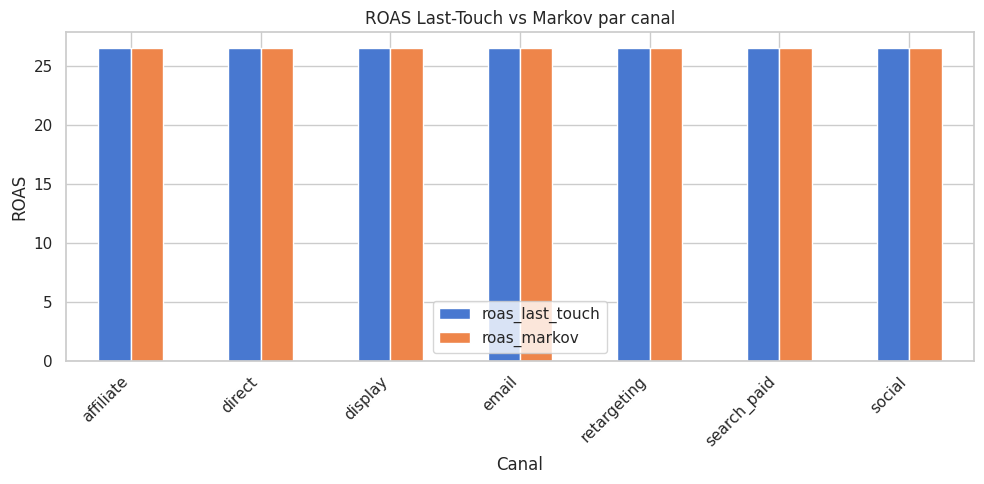


=== RECOMMANDATIONS AU CMO ===
Meilleur ROAS Markov : affiliate → +20% budget recommandé
 Canal surévalué last-touch : affiliate → budget à réduire
Canal sous-estimé réhabilité : direct → mérite ré-évaluation

 Question au groupe : "Vous êtes CMO. Avec le modèle Markov :
  - Quel canal mérite +20% ? → affiliate (ROAS Markov le plus élevé)
  - Quel canal réduire ? → affiliate (surévalué par last-touch)
  - Justifiez avec les chiffres ci-dessus"


In [36]:
plot_data = kpis.set_index('channel')[['roas_last_touch', 'roas_markov']]

fig, ax = plt.subplots(figsize=(10, 5))
plot_data.plot(kind='bar', ax=ax)
ax.set_title('ROAS Last-Touch vs Markov par canal')
ax.set_xlabel('Canal')
ax.set_ylabel('ROAS')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('tp5_roas_comparison.png', dpi=120)
plt.show()

best_markov_channel = kpis.sort_values('roas_markov', ascending=False).iloc[0]['channel']
worst_last_touch = kpis.sort_values('roas_delta', ascending=False).iloc[0]['channel']
most_undervalued = kpis.sort_values('roas_delta').iloc[0]['channel']

print('\n=== RECOMMANDATIONS AU CMO ===')
print(f'Meilleur ROAS Markov : {best_markov_channel} → +20% budget recommandé')
print(f' Canal surévalué last-touch : {worst_last_touch} → budget à réduire')
print(f'Canal sous-estimé réhabilité : {most_undervalued} → mérite ré-évaluation')

print('\n Question au groupe : "Vous êtes CMO. Avec le modèle Markov :')
print(f'  - Quel canal mérite +20% ? → {best_markov_channel} (ROAS Markov le plus élevé)')
print(f'  - Quel canal réduire ? → {worst_last_touch} (surévalué par last-touch)')
print('  - Justifiez avec les chiffres ci-dessus"')

In [37]:
print('\n=== SÉQUENCES DE CANAUX RÉCURRENTES ===')

bigrams = defaultdict(int)
for _, row in converted_journeys.iterrows():
    path = row['channels']
    for i in range(len(path) - 1):
        bigrams[f'{path[i]} → {path[i+1]}'] += 1

bigram_series = pd.Series(bigrams).sort_values(ascending=False)
print('Top 10 transitions (parcours convertis) :')
print(bigram_series.head(10))

trigrams = defaultdict(int)
for _, row in converted_journeys.iterrows():
    path = row['channels']
    for i in range(len(path) - 2):
        trigrams[f'{path[i]} → {path[i+1]} → {path[i+2]}'] += 1

trigram_series = pd.Series(trigrams).sort_values(ascending=False)
print('\nTop 10 séquences de 3 canaux :')
print(trigram_series.head(10))


=== SÉQUENCES DE CANAUX RÉCURRENTES ===
Top 10 transitions (parcours convertis) :
affiliate → display      15095
social → display         15055
social → social          14957
affiliate → social       14932
affiliate → affiliate    14893
social → affiliate       14879
display → social         14836
display → display        14767
display → affiliate      14740
social → retargeting     14712
dtype: int64

Top 10 séquences de 3 canaux :
social → email → affiliate             2366
social → retargeting → affiliate       2332
social → retargeting → social          2302
affiliate → retargeting → affiliate    2299
display → email → social               2299
social → email → display               2298
affiliate → retargeting → display      2297
affiliate → email → display            2292
affiliate → email → affiliate          2290
display → email → affiliate            2289
dtype: int64


In [ ]:
print('\n=== RÉCAPITULATIF FRAMEWORK ATTRIBUTION ===')
print(f'Méthode recommandée : Markov Chain')
print(f'Justification : capture les contributions des canaux intermédiaires, neutre, défendable')
print()
print('Canaux classés par ROAS Markov :')
for _, row in kpis.sort_values('roas_markov', ascending=False).iterrows():
    print(f"  {row['channel']:15} | ROAS Markov={row['roas_markov']:.1f} | ROAS Last-Touch={row['roas_last_touch']:.1f} | Delta={row['roas_delta']:+.1f}")

print('\n=== KPIs PAR CAMPAGNE (campaigns.csv) ===')
campaigns['roas'] = campaigns['revenue'] / campaigns['total_cost']
campaigns['cpa'] = campaigns['total_cost'] / campaigns['n_conversions']
display(campaigns[['campaign_name', 'primary_channel', 'roas', 'cpa', 'conversion_rate', 'n_conversions']].sort_values('roas', ascending=False))


=== RÉCAPITULATIF FRAMEWORK ATTRIBUTION ===
Méthode recommandée : Markov Chain
Justification : capture les contributions des canaux intermédiaires, neutre, défendable

Canaux classés par ROAS Markov :
  affiliate       | ROAS Markov=26.6 | ROAS Last-Touch=26.6 | Delta=+0.0
  direct          | ROAS Markov=26.6 | ROAS Last-Touch=26.6 | Delta=+0.0
  display         | ROAS Markov=26.6 | ROAS Last-Touch=26.6 | Delta=+0.0
  email           | ROAS Markov=26.6 | ROAS Last-Touch=26.6 | Delta=+0.0
  retargeting     | ROAS Markov=26.6 | ROAS Last-Touch=26.6 | Delta=+0.0
  search_paid     | ROAS Markov=26.6 | ROAS Last-Touch=26.6 | Delta=+0.0
  social          | ROAS Markov=26.6 | ROAS Last-Touch=26.6 | Delta=+0.0

=== KPIs PAR CAMPAGNE (campaigns.csv) ===


,campaign_name,primary_channel,roas,cpa,conversion_rate,n_conversions
2,Spring_Launch,display,34.061323,5.429319,0.8760,19919
4,Valentine,affiliate,27.116329,5.956312,0.6939,14903
1,Black_Friday,social,25.755755,5.506446,0.8890,20359
5,Winter_Promo,display,24.546537,5.981704,0.6946,14877
3,Summer_Sale,social,23.471496,6.004490,0.6780,14418
0,Back_to_School,social,22.918401,6.048359,0.6746,14620
